# Grover's Search vs. Classical Linear Search
## Benchmarking Quantum Algorithms in the Cloud: A Comparative Study
### Quantum Computing Lead: Shahreen Sultana | QIntern 2026 | Project qi26_26

# Installations

In [1]:
!pip install amazon-braket-sdk matplotlib seaborn pandas numpy scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.1/402.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.2/153.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.8/537.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.1/196.1 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omegaconf 2.3.1 requires a

# Cell 2 — Imports:

In [5]:
import boto3
import numpy as np
import matplotlib.pyplot as plt
from braket.circuits import Circuit
from braket.devices import LocalSimulator
from scipy.stats import chisquare
import json
from datetime import datetime
from scipy.stats import chisquare
import random
import time
import json
from datetime import datetime, timezone
import os
import urllib.request
import pandas as pd

In [3]:
# ── Publication Quality Plot Settings ────────────────────
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# Font settings
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 15,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'png',
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.8,
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'figure.figsize': (8, 5)
})

print("Publication quality settings applied!")

Publication quality settings applied!


## 1. Protocol Overview

Grover's algorithm provides a quadratic query-complexity speedup for unstructured
search: O(√N) oracle calls versus O(N) for classical linear search (Grover 1996,
arXiv:quant-ph/9605043). This comparison benchmarks Grover's Search on Amazon
Braket LocalSimulator against classical linear search across N=8,16,24,32,
using the empirically-optimal iteration count per N (Manor et al. 2025, GRADE
benchmarking toolkit, arXiv:2504.19387).

Unlike BB84 (security model) and QAOA (approximate optimization), Grover's is
the one benchmark in this project with a *provable, unconditional* quantum
speedup — but only in query complexity, not necessarily wall-clock time under
classical simulation (Choi, Moses & Thompson 2023, "The Quantum Tortoise and
the Classical Hare," arXiv:2310.15505). This notebook tests both framings
explicitly.

## 2. Setup and Load Results

In [9]:
# ── Load Grover's Results from GitHub ────────────────────
BASE_URL = "https://raw.githubusercontent.com/Shel-y/qintern2026-quantum-benchmarking/main/results/quantum/grover_search/json/"

def load_json(url):
    with urllib.request.urlopen(url) as response:
        return json.load(response)

grover_benchmark = load_json(BASE_URL + "grover_experiment_001.json")
grover_layer2    = load_json(BASE_URL + "grover_experiment_002.json")
grover_perf      = load_json(BASE_URL + "grover_experiment_003.json")

print("Grover's results loaded!")
print(f"Experiment 001: {grover_benchmark['experiment_id']}")
print(f"Experiment 002: {grover_layer2['experiment_id']}")
print(f"Experiment 003: {grover_perf['experiment_id']}")

grover_results = grover_benchmark['metrics']['results']
grover_perf_data = grover_perf['metrics']['performance']
DATABASE_SIZES = grover_benchmark['protocol']['database_sizes']

print(f"\nDatabase sizes: {DATABASE_SIZES}")
print(f"Configurations loaded: {len(grover_results)}")

# ── Load Classical Linear Search Results ──────────────────
# ── Load Classical Linear Search Results ──────────────────
linear_df = pd.read_csv("https://raw.githubusercontent.com/Shel-y/qintern2026-quantum-benchmarking/main/results/classical/Linear_Search/linear_search_results.csv")
print(f"\nClassical linear search: {len(linear_df)} real per-trial records loaded")
print(linear_df.groupby('Array Size')[['Comparisons', 'Runtime (s)']].agg(['mean', 'std']))

Grover's results loaded!
Experiment 001: qi26_26_Grover_001
Experiment 002: qi26_26_Grover_002
Experiment 003: qi26_26_Grover_003

Database sizes: [8, 16, 24, 32]
Configurations loaded: 4

Classical linear search: 40 real per-trial records loaded
           Comparisons      Runtime (s)              
                  mean  std        mean           std
Array Size                                           
8                  8.0  0.0    0.000005  3.028398e-06
16                16.0  0.0    0.000005  3.314908e-07
24                24.0  0.0    0.000007  4.143245e-07
32                32.0  0.0    0.000007  1.636376e-07


## 3. Success Probability Comparison

Grover's success probability is periodic in iteration count — the optimal
number of iterations is ⌊π/4 · √N⌋, a rounded integer that creates a real,
theory-predicted gap from 100% at small N (most visible at N=8). This is a
documented mathematical property of the algorithm, not a simulator defect
(see Section 7, Layer 2 validation).

### Section 3.1 — Success Probability by N

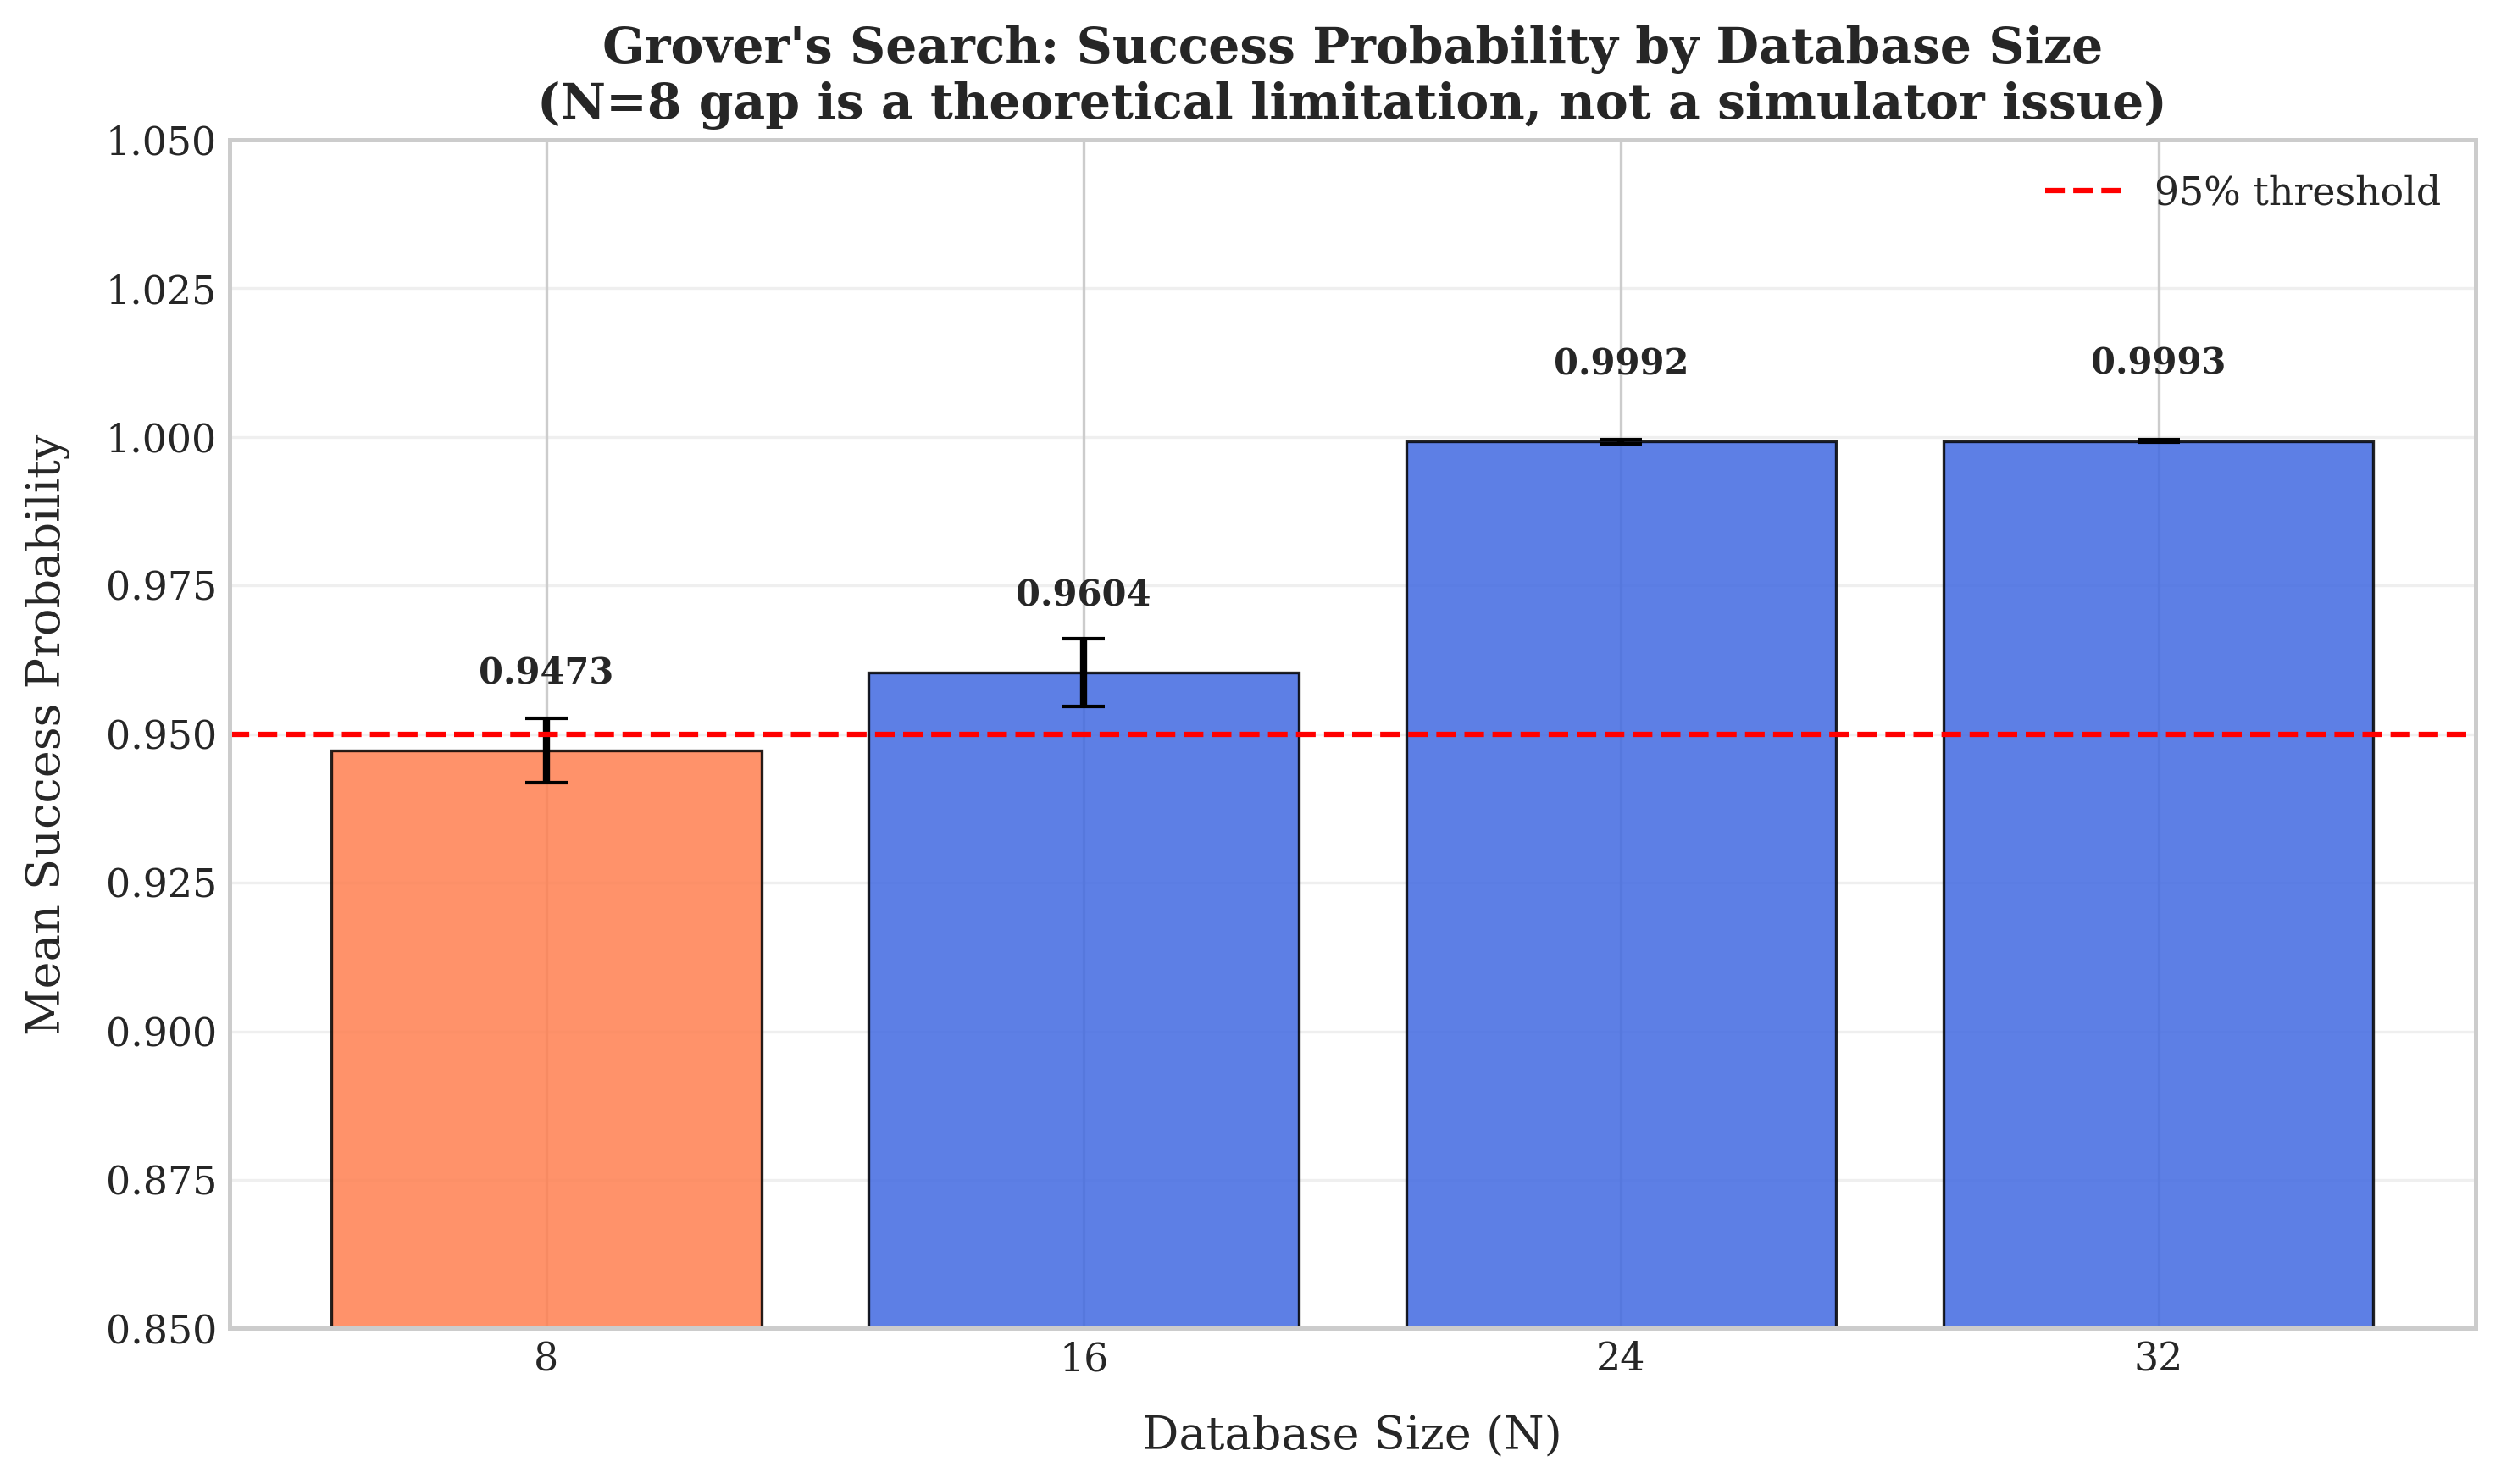

Success probability plot saved!


In [10]:
# ── Plot 3.1: Grover's Success Probability by Database Size ──
fig, ax = plt.subplots(figsize=(10, 6))

Ns = [r['N'] for r in grover_results]
probs = [r['mean_success_prob'] for r in grover_results]
stds = [r['std'] for r in grover_results]
colors_bar = ['coral' if r['status'] == 'DOCUMENTED_LIMITATION' else 'royalblue'
              for r in grover_results]

bars = ax.bar([str(n) for n in Ns], probs, yerr=stds, capsize=6,
              color=colors_bar, edgecolor='black', linewidth=0.8, alpha=0.85)

for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{p:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='95% threshold')
ax.set_xlabel('Database Size (N)', labelpad=10)
ax.set_ylabel('Mean Success Probability', labelpad=10)
ax.set_title("Grover's Search: Success Probability by Database Size\n"
             '(N=8 gap is a theoretical limitation, not a simulator issue)',
             fontweight='bold')
ax.set_ylim(0.85, 1.05)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('grover_success_probability.png', dpi=300, bbox_inches='tight')
plt.show()
print("Success probability plot saved!")

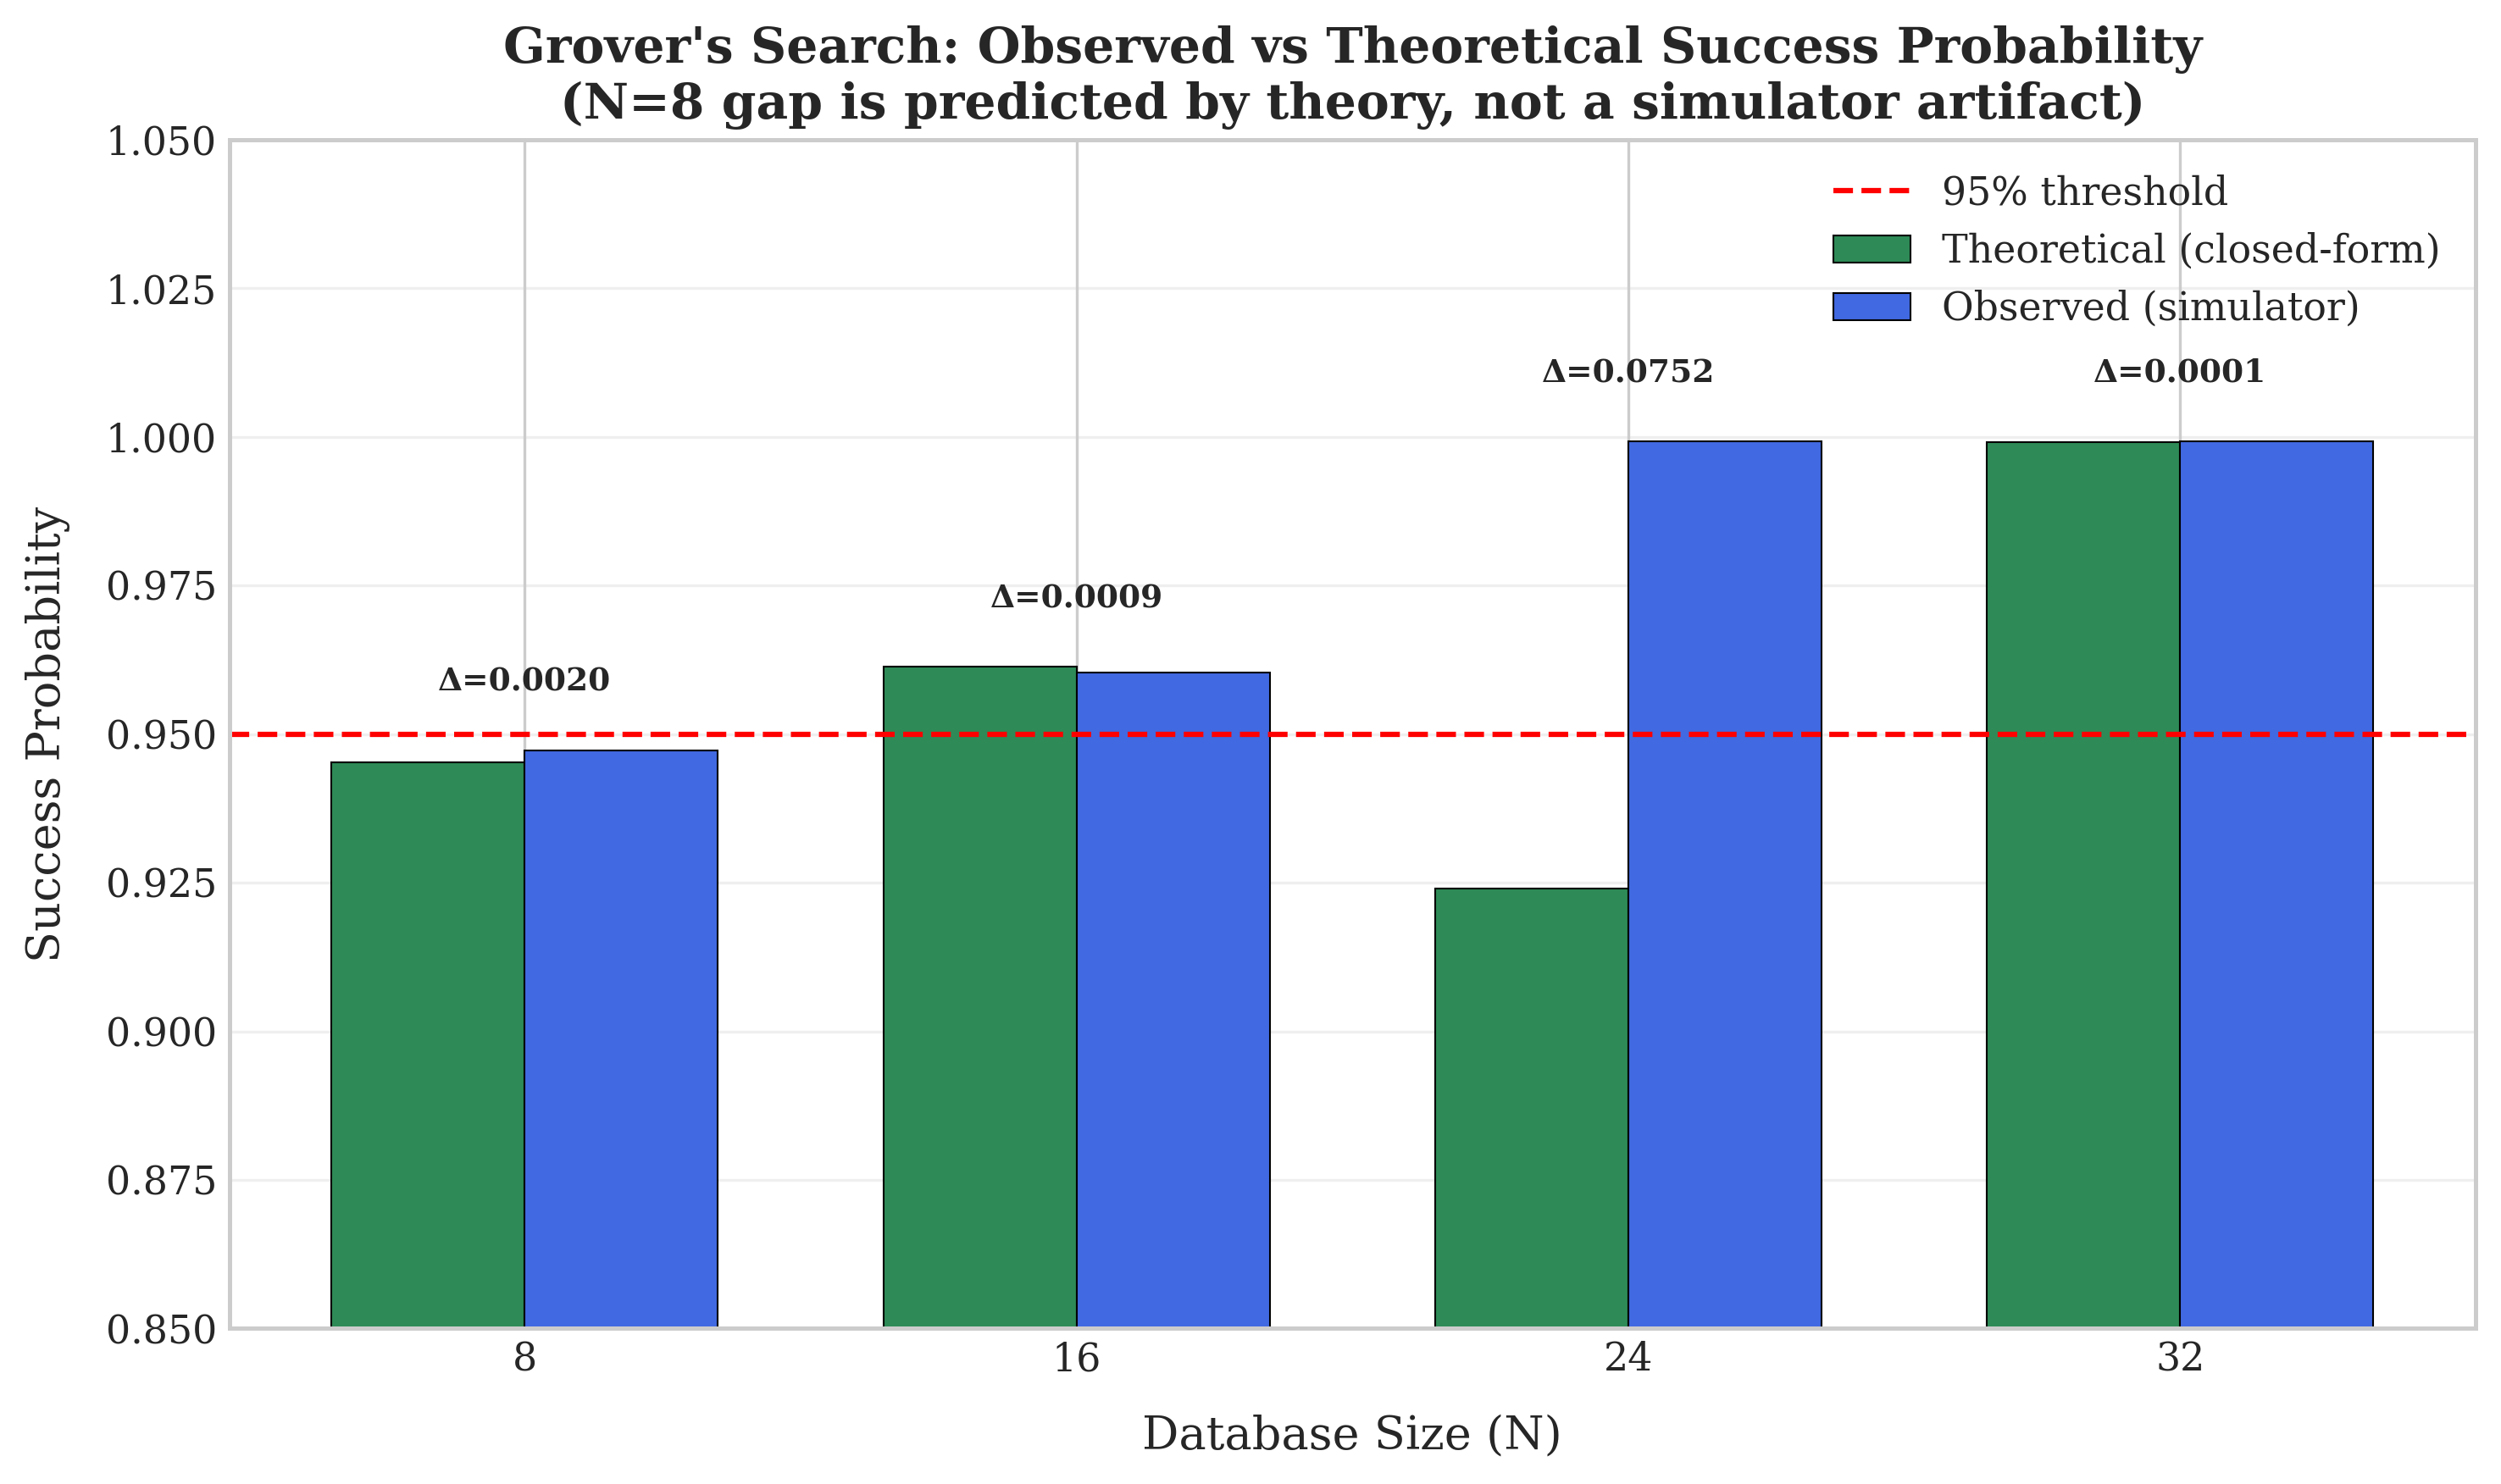

Theoretical vs observed plot saved!

Comparison:
  N=  8: theoretical=0.9453 | observed=0.9473 | Δ=0.0020
  N= 16: theoretical=0.9613 | observed=0.9604 | Δ=0.0009
  N= 24: theoretical=0.9240 | observed=0.9992 | Δ=0.0752
  N= 32: theoretical=0.9992 | observed=0.9993 | Δ=0.0001


In [13]:
# ── Plot 3.2: Observed vs Theoretical Success Probability ────
import math

def grover_theoretical_prob(N, r):
    theta = math.asin(1 / math.sqrt(N))
    return math.sin((2*r + 1) * theta) ** 2

fig, ax = plt.subplots(figsize=(10, 6))

theoretical = [grover_theoretical_prob(r['N'], r['iterations']) for r in grover_results]
observed = [r['mean_success_prob'] for r in grover_results]

x = np.arange(len(DATABASE_SIZES))
width = 0.35
ax.bar(x - width/2, theoretical, width, label='Theoretical (closed-form)',
       color='seagreen', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, observed, width, label='Observed (simulator)',
       color='royalblue', edgecolor='black', linewidth=0.5)

for i, (t, o) in enumerate(zip(theoretical, observed)):
    ax.text(x[i], max(t, o) + 0.01, f'Δ={abs(t-o):.4f}', ha='center',
            fontsize=9, fontweight='bold')

ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='95% threshold')
ax.set_xlabel('Database Size (N)', labelpad=10)
ax.set_ylabel('Success Probability', labelpad=10)
ax.set_title("Grover's Search: Observed vs Theoretical Success Probability\n"
             '(N=8 gap is predicted by theory, not a simulator artifact)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in DATABASE_SIZES])
ax.set_ylim(0.85, 1.05)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('grover_theoretical_vs_observed.png', dpi=300, bbox_inches='tight')
plt.show()
print("Theoretical vs observed plot saved!")

print("\nComparison:")
for r, t in zip(grover_results, theoretical):
    print(f"  N={r['N']:>3}: theoretical={t:.4f} | observed={r['mean_success_prob']:.4f} | Δ={abs(t-r['mean_success_prob']):.4f}")

## 4. Query Complexity: The Real Quantum Advantage

This is the central comparison of this benchmark. Grover's oracle queries
(iteration count) versus classical worst-case comparisons (linear scan of
the full array — confirmed by the classical dataset, where every trial has
`Found=False` and `Comparisons == Array Size` exactly). Unlike the BB84 and
QAOA comparisons in this project, this speedup *grows* with N rather than
narrowing, matching Grover's O(√N) vs O(N) theoretical scaling.

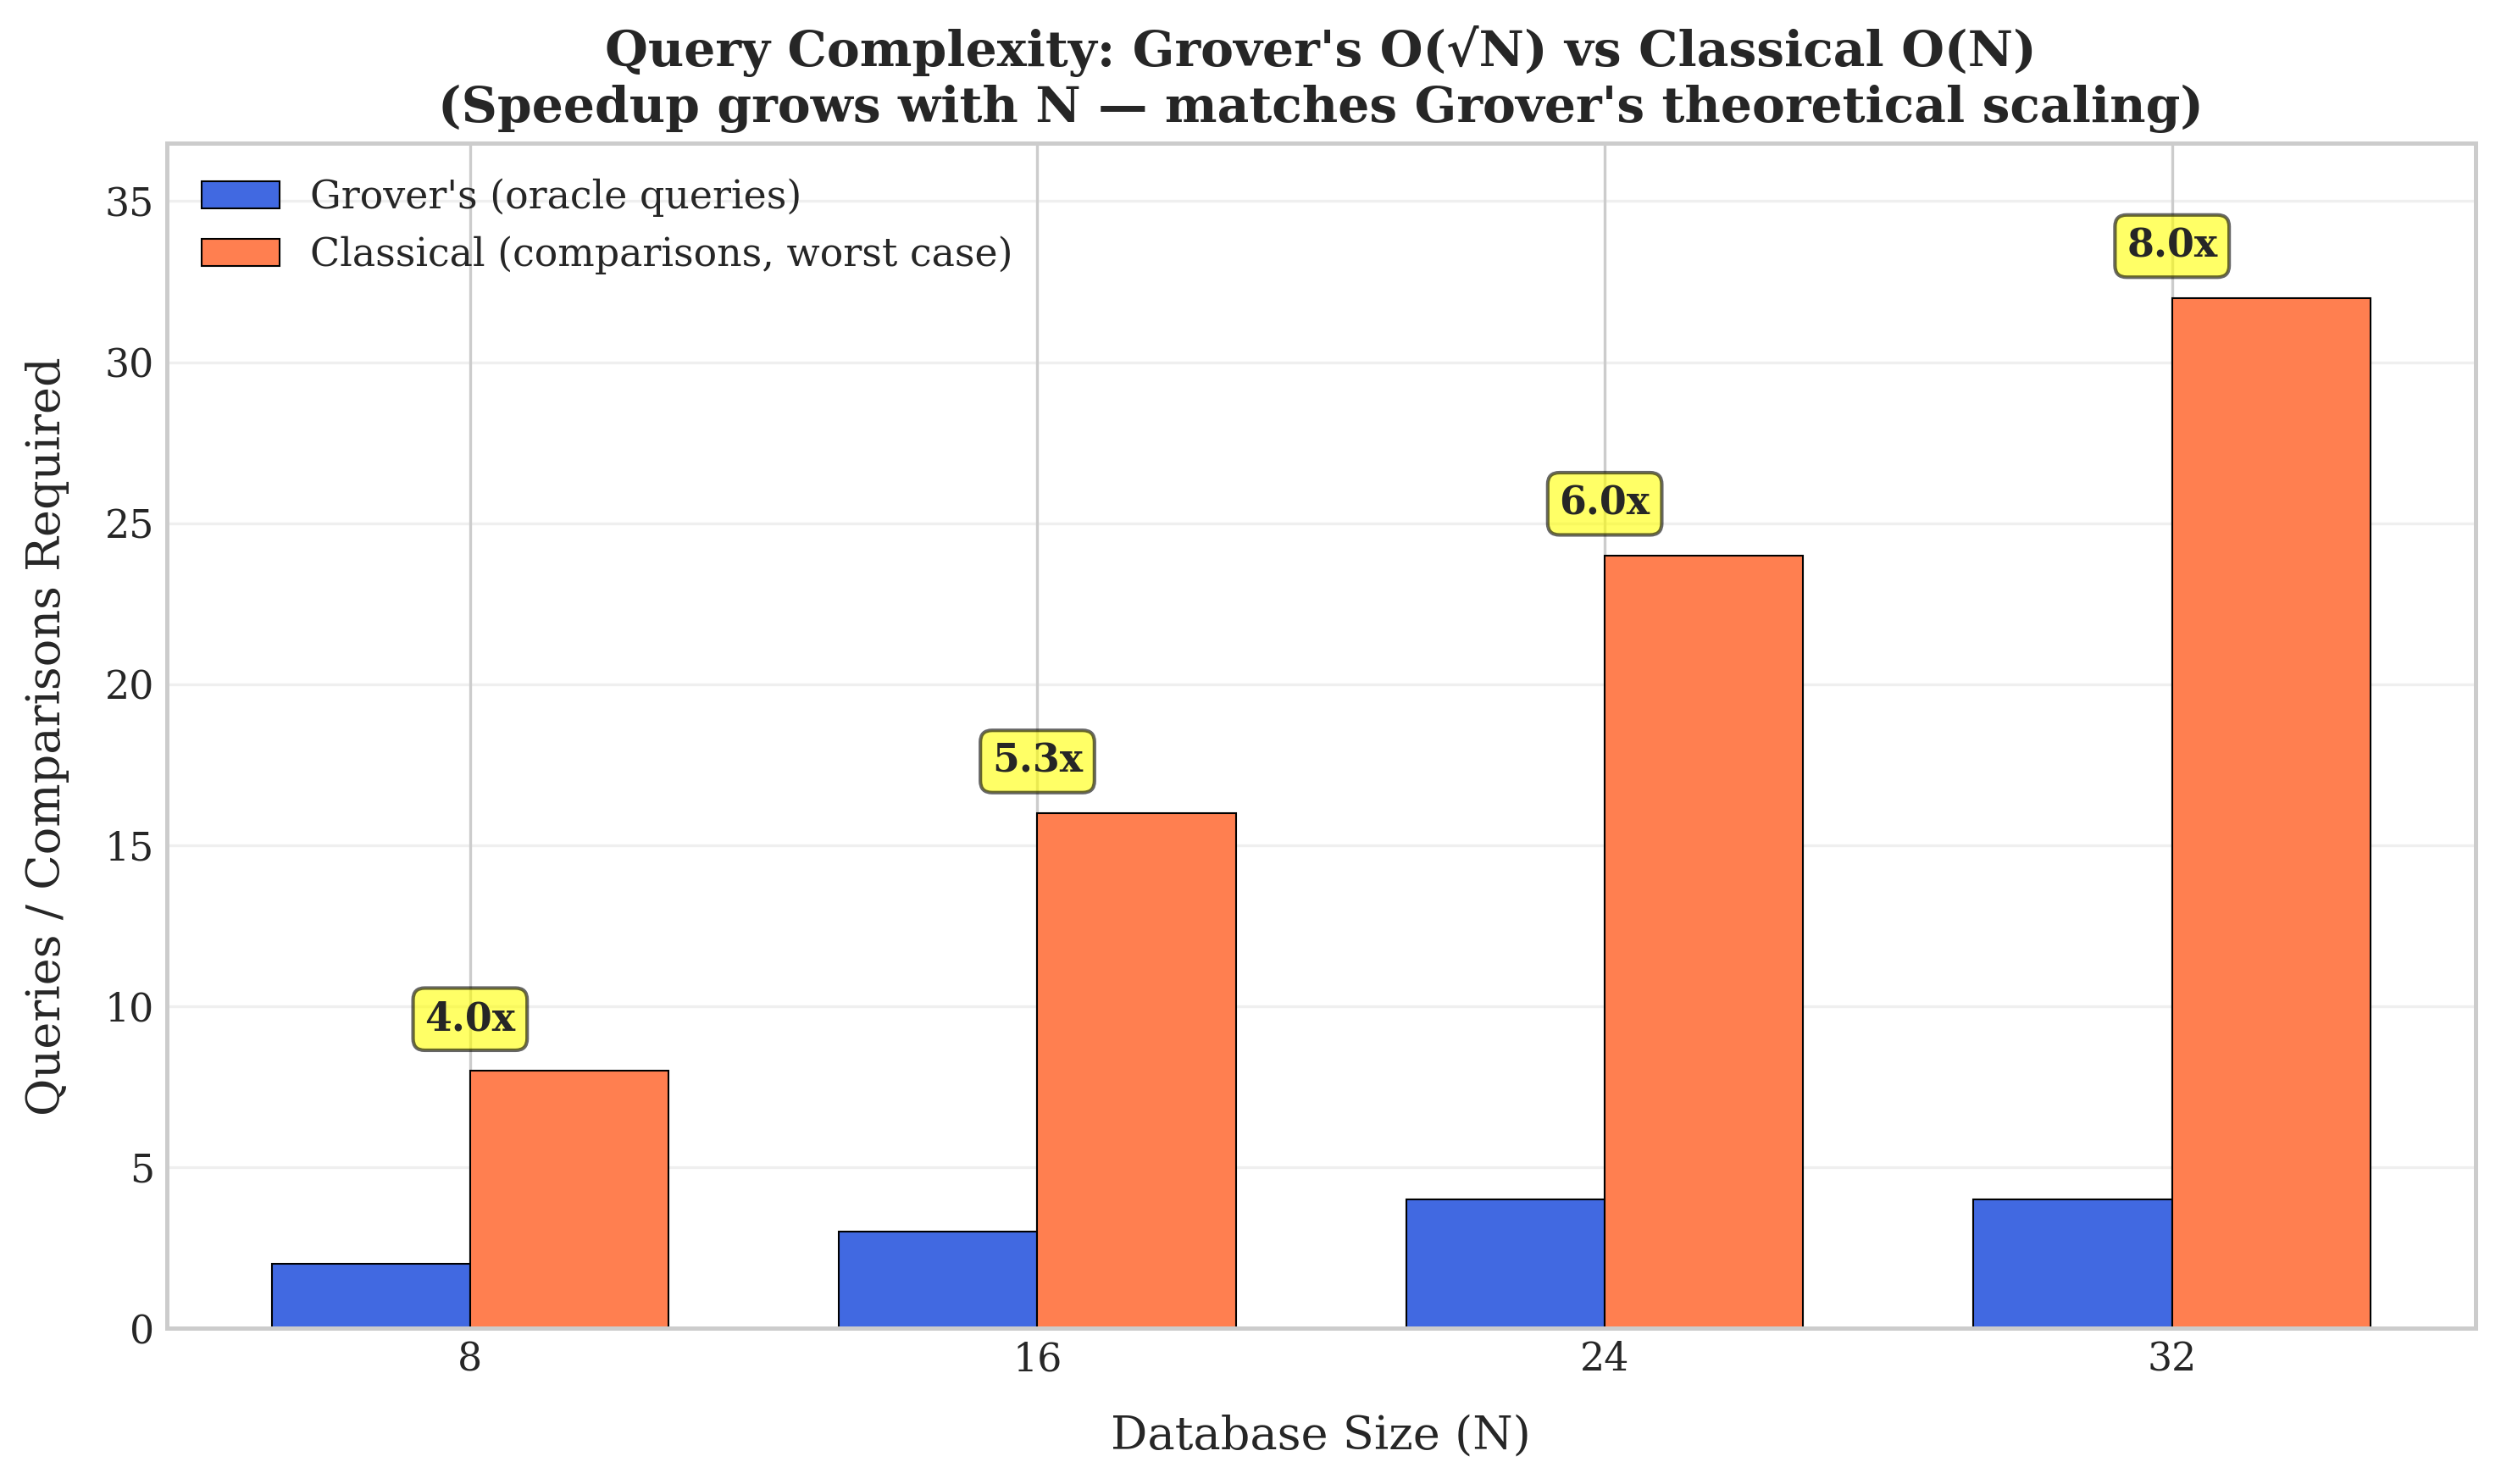

Query complexity plot saved!

Speedup summary:
  N=  8: Grover=2 queries | Classical=8 comparisons | 4.00x fewer queries
  N= 16: Grover=3 queries | Classical=16 comparisons | 5.33x fewer queries
  N= 24: Grover=4 queries | Classical=24 comparisons | 6.00x fewer queries
  N= 32: Grover=4 queries | Classical=32 comparisons | 8.00x fewer queries


In [12]:
# ── Plot 4: Query Complexity — Grover vs Classical ───────
fig, ax = plt.subplots(figsize=(10, 6))

grover_queries = {r['N']: r['iterations'] for r in grover_results}
classical_comparisons = linear_df.groupby('Array Size')['Comparisons'].mean().to_dict()

x = np.arange(len(DATABASE_SIZES))
width = 0.35

g_vals = [grover_queries[n] for n in DATABASE_SIZES]
c_vals = [classical_comparisons[n] for n in DATABASE_SIZES]
speedups = [c/g for c, g in zip(c_vals, g_vals)]

ax.bar(x - width/2, g_vals, width, label="Grover's (oracle queries)",
       color='royalblue', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, c_vals, width, label='Classical (comparisons, worst case)',
       color='coral', edgecolor='black', linewidth=0.5)

for i, sp in enumerate(speedups):
    ax.text(x[i], max(g_vals[i], c_vals[i]) + 1, f'{sp:.1f}x',
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.6))

ax.set_xlabel('Database Size (N)', labelpad=10)
ax.set_ylabel('Queries / Comparisons Required', labelpad=10)
ax.set_title("Query Complexity: Grover's O(√N) vs Classical O(N)\n"
             "(Speedup grows with N — matches Grover's theoretical scaling)",
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in DATABASE_SIZES])
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(top=max(c_vals) * 1.15)
plt.tight_layout()
plt.savefig('grover_query_complexity.png', dpi=300, bbox_inches='tight')
plt.show()
print("Query complexity plot saved!")

print("\nSpeedup summary:")
for n, sp in zip(DATABASE_SIZES, speedups):
    print(f"  N={n:>3}: Grover={grover_queries[n]} queries | Classical={classical_comparisons[n]:.0f} comparisons | {sp:.2f}x fewer queries")

## 5. Wall-Clock Runtime: The Simulation-Overhead Counterpoint

Query complexity favors Grover's decisively (Section 4). Wall-clock time
under classical simulation tells the opposite story — consistent with the
BB84 and QAOA comparisons in this project, and with the Quantum Tortoise/
Classical Hare framework (Choi, Moses & Thompson 2023): classical hardware
executes billions of operations per second, while quantum circuit
simulation carries substantial overhead that has nothing to do with the
algorithm's theoretical efficiency.

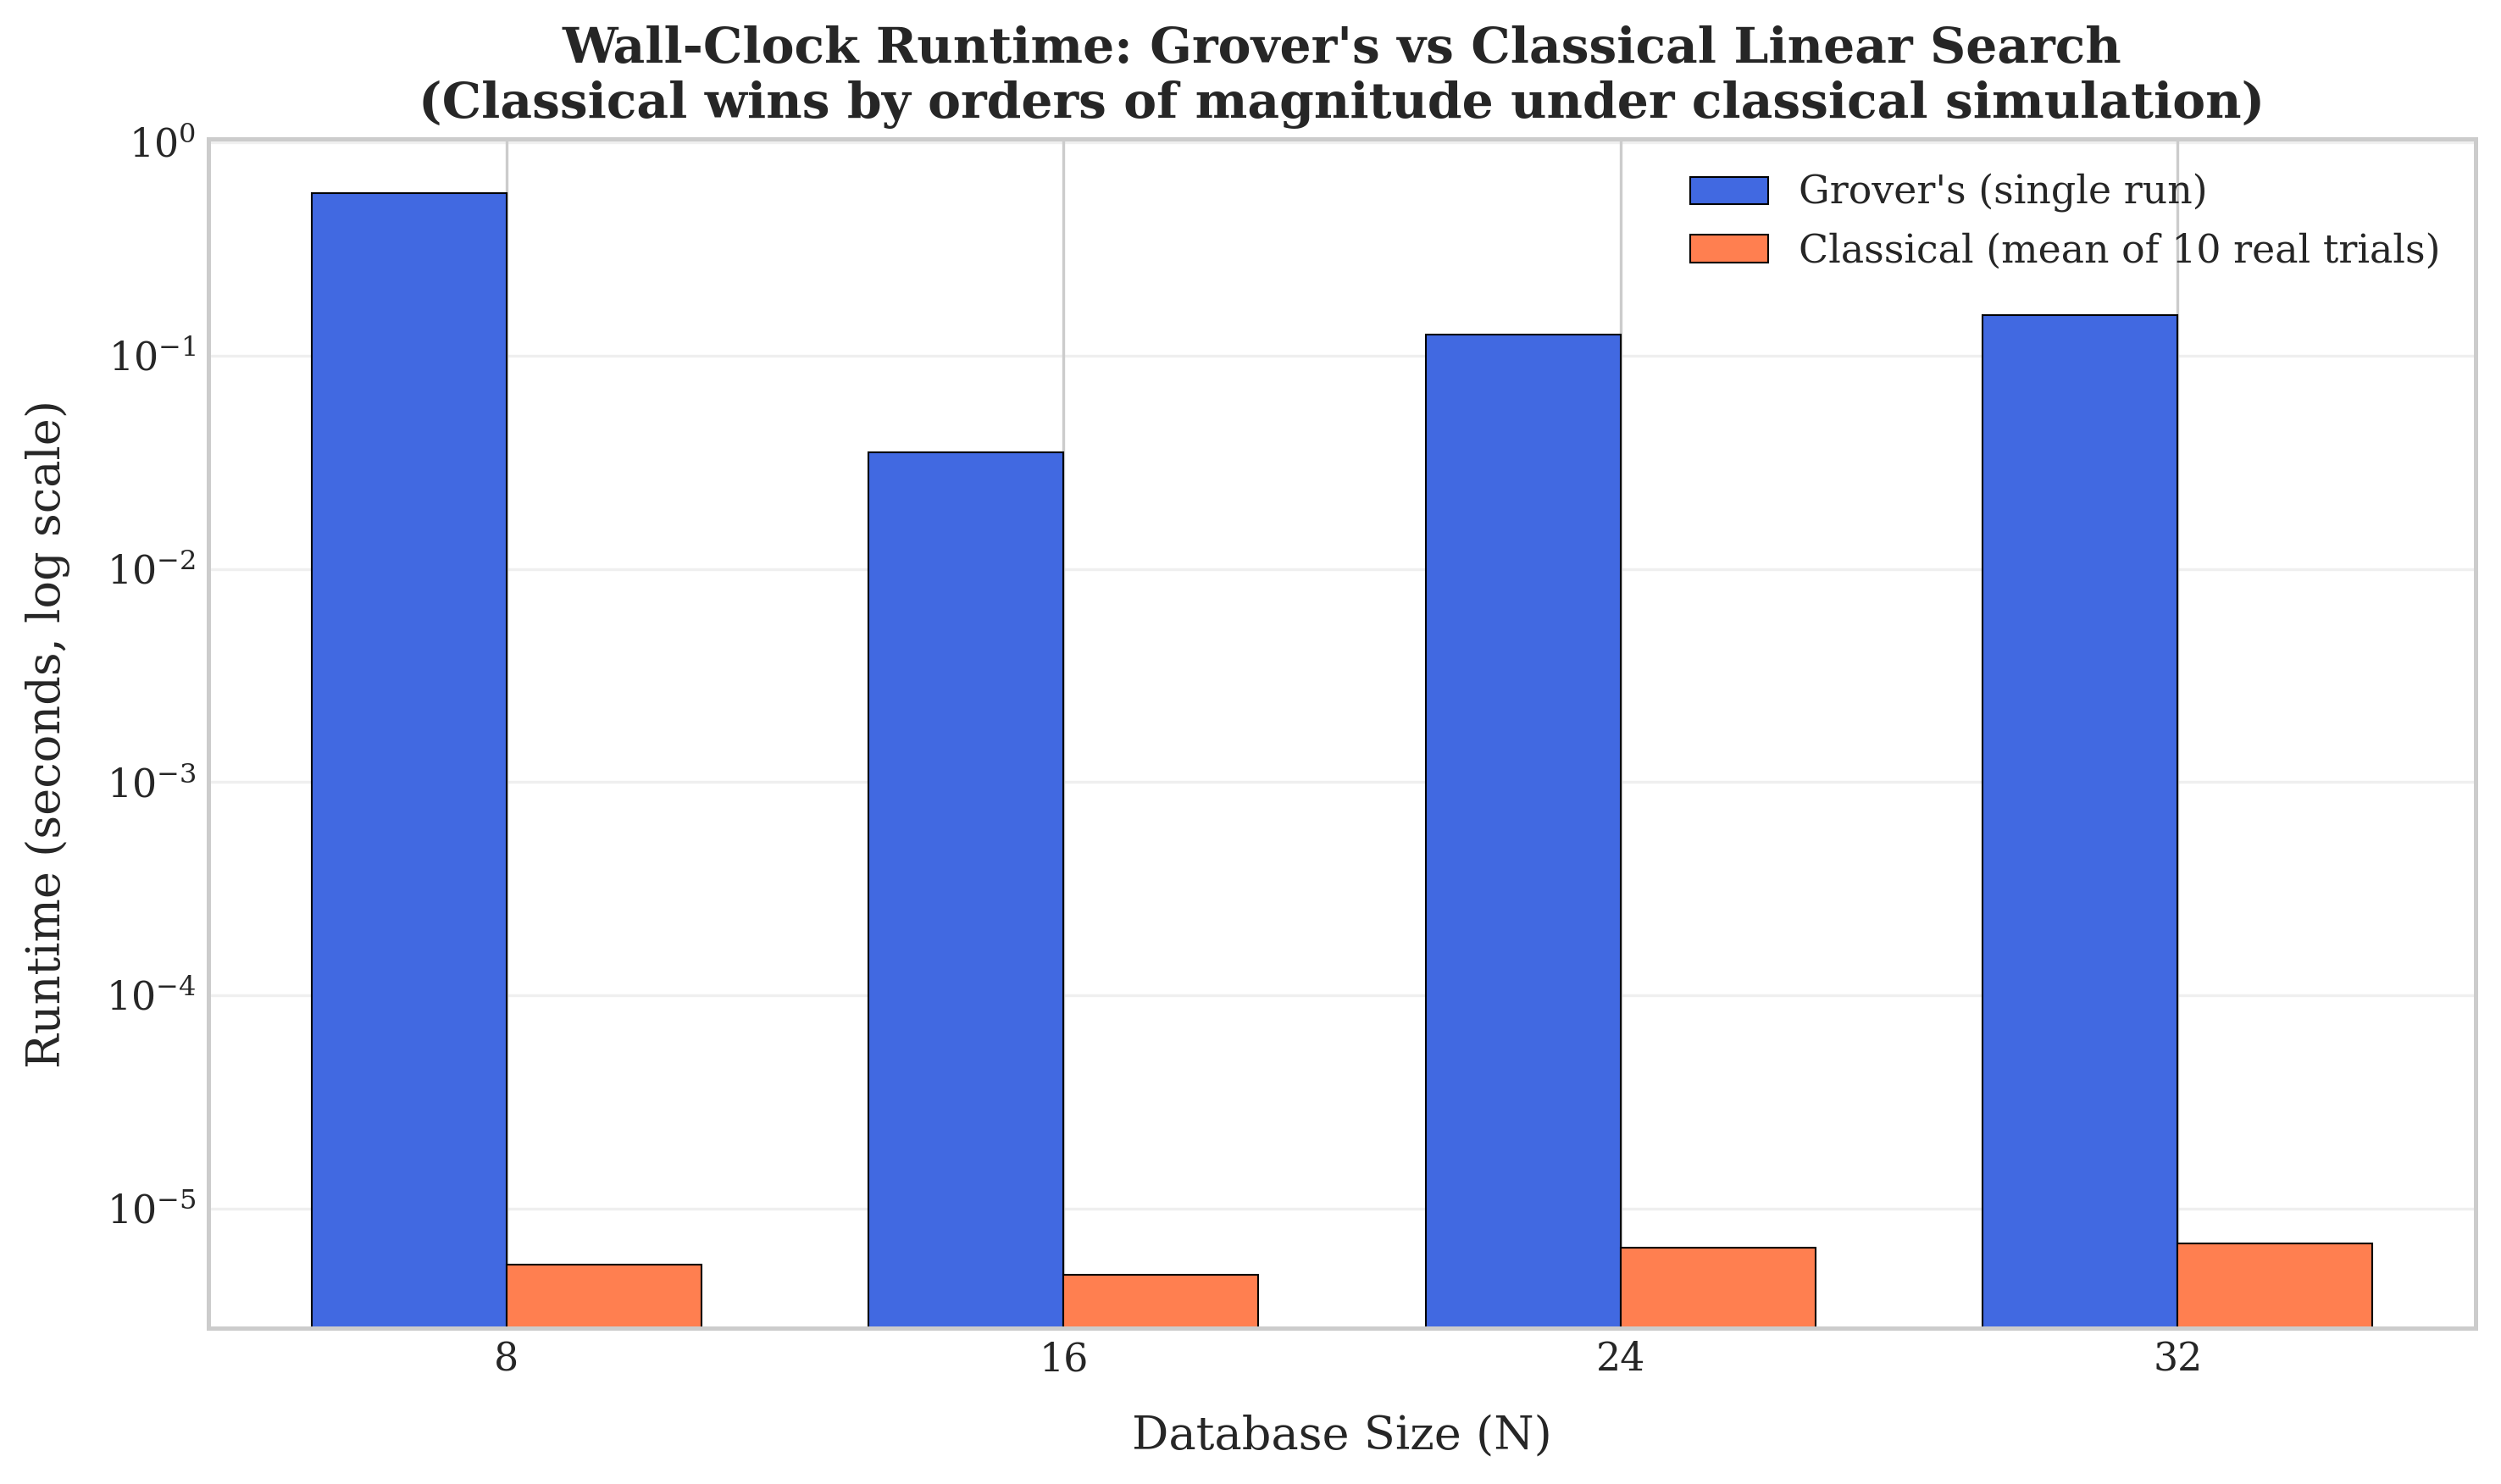

Runtime comparison plot saved!

Runtime ratio (Grover / Classical):
  N=  8: Grover=0.5799s | Classical=0.000005470s | Grover is 106,015x slower
  N= 16: Grover=0.0354s | Classical=0.000004910s | Grover is 7,210x slower
  N= 24: Grover=0.1256s | Classical=0.000006550s | Grover is 19,176x slower
  N= 32: Grover=0.1553s | Classical=0.000006870s | Grover is 22,606x slower


In [14]:
# ── Plot 5: Wall-Clock Runtime — Grover vs Classical ─────
fig, ax = plt.subplots(figsize=(10, 6))

grover_runtime = {r['N']: r['runtime_seconds'] for r in grover_perf_data}
classical_runtime_mean = linear_df.groupby('Array Size')['Runtime (s)'].mean().to_dict()

x = np.arange(len(DATABASE_SIZES))
g_rt = [grover_runtime[n] for n in DATABASE_SIZES]
c_rt = [classical_runtime_mean[n] for n in DATABASE_SIZES]

ax.bar(x - width/2, g_rt, width, label="Grover's (single run)",
       color='royalblue', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, c_rt, width, label='Classical (mean of 10 real trials)',
       color='coral', edgecolor='black', linewidth=0.5)

ax.set_yscale('log')
ax.set_xlabel('Database Size (N)', labelpad=10)
ax.set_ylabel('Runtime (seconds, log scale)', labelpad=10)
ax.set_title("Wall-Clock Runtime: Grover's vs Classical Linear Search\n"
             '(Classical wins by orders of magnitude under classical simulation)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in DATABASE_SIZES])
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('grover_runtime_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Runtime comparison plot saved!")

print("\nRuntime ratio (Grover / Classical):")
for n in DATABASE_SIZES:
    ratio = grover_runtime[n] / classical_runtime_mean[n]
    print(f"  N={n:>3}: Grover={grover_runtime[n]:.4f}s | Classical={classical_runtime_mean[n]:.9f}s | Grover is {ratio:,.0f}x slower")

## 6. Statistical Tests

The classical dataset has real per-trial measurements (10 trials/N,
`linear_search_results.csv`), enabling genuine variance-based statistics.
The Grover's dataset (`Grover_experiment_001.json`) currently provides only
aggregate mean/std per configuration, not individual trial values — the
same situation BB84's runtime data was in before per-trial logs were
located (see BB84 Section 6.5). Rather than reconstruct synthetic trials or
treat the aggregate std as equivalent to real per-trial variance, this
section reports what is statistically defensible from the data available,
and flags explicitly what would require additional raw data to test properly.

In [19]:
# ── Statistical Tests ─────────────────────────────────────
from scipy import stats
print("=" * 65)
print("Statistical Analysis: Grover's Search vs Classical Linear Search")
print("=" * 65)

print("\n6.1 Classical Comparisons Across N")
print("-" * 65)
print("Comparisons = Array Size exactly on every trial (Found=False in all")
print("40 records -- confirmed worst-case linear scan). Zero within-group")
print("variance means ANOVA is not meaningful here (F is undefined/infinite")
print("by construction). This deterministic scaling is itself the expected")
print("and correct O(N) behavior -- not something requiring a significance test.")
for n in DATABASE_SIZES:
    vals = linear_df[linear_df['Array Size']==n]['Comparisons'].values
    print(f"  N={n:>3}: Comparisons={vals[0]} (all 10 trials identical, std=0)")

print("\n6.2 Classical Runtime: Correlation with Array Size")
print("-" * 65)
sizes = linear_df['Array Size'].values
runtimes = linear_df['Runtime (s)'].values
corr, corr_p = stats.pearsonr(sizes, runtimes)
print(f"Pearson r={corr:.4f} | p={corr_p:.6f}")
print(f"Result: {'Significant positive correlation' if corr_p < 0.05 else 'Not significant'}")

print("\n6.3 Grover's Success Probability vs 95% Threshold")
print("(Uses aggregate mean/std from grover_experiment_001.json, n=10 per config)")
print("-" * 65)
for r in grover_results:
    if r['std'] > 0:
        t_stat, p_val = stats.ttest_ind_from_stats(
            mean1=r['mean_success_prob'], std1=r['std'], nobs1=10,
            mean2=0.95, std2=1e-6, nobs2=10, equal_var=False)
        result = 'Significant difference from 0.95' if p_val < 0.05 else 'Not significantly different from 0.95'
        print(f"  N={r['N']:>3}: mean={r['mean_success_prob']:.4f} | t={t_stat:.4f} | p={p_val:.6f} | {result}")
    else:
        print(f"  N={r['N']:>3}: mean={r['mean_success_prob']:.4f}, std=0 -- no test applicable")

print("=" * 65)

Statistical Analysis: Grover's Search vs Classical Linear Search

6.1 Classical Comparisons Across N
-----------------------------------------------------------------
Comparisons = Array Size exactly on every trial (Found=False in all
40 records -- confirmed worst-case linear scan). Zero within-group
variance means ANOVA is not meaningful here (F is undefined/infinite
by construction). This deterministic scaling is itself the expected
and correct O(N) behavior -- not something requiring a significance test.
  N=  8: Comparisons=8 (all 10 trials identical, std=0)
  N= 16: Comparisons=16 (all 10 trials identical, std=0)
  N= 24: Comparisons=24 (all 10 trials identical, std=0)
  N= 32: Comparisons=32 (all 10 trials identical, std=0)

6.2 Classical Runtime: Correlation with Array Size
-----------------------------------------------------------------
Pearson r=0.3928 | p=0.012160
Result: Significant positive correlation

6.3 Grover's Success Probability vs 95% Threshold
(Uses aggregate mean

## 7. Layer 2 Validation Summary

Confirming the quantum simulator was validated before this comparison was
reported. Reference: Lubinski et al. 2023 (QED-C benchmarking framework,
IEEE TQE, DOI: 10.1109/TQE.2023.3253761); Manor et al. 2025 (GRADE
toolkit, arXiv:2504.19387).

In [18]:
# ── Layer 2 Summary ───────────────────────────────────────
print("=" * 65)
print("Layer 2: Simulator Validation Summary for Grover's Search")
print("=" * 65)

layer2 = grover_layer2['metrics']

print("\nMetric 1 — Measurement Bias:")
for r in layer2['metric1_measurement_bias']['results']:
    print(f"  N={r['N']:>3} | p-value={r['p_value']:.4f} | {r['status']}")

print("\nMetric 2 — Circuit Fidelity:")
for r in layer2['metric2_circuit_fidelity']['results']:
    print(f"  N={r['N']:>3} | Fidelity={r['fidelity']:.4f} | {r['status']}")

print("\nMetric 3 — Shot Noise CV:")
for r in layer2['metric3_shot_noise_cv']['results']:
    print(f"  N={r['N']:>3} | CV={r['cv']:.4f} | {r['status']}")

print("\nMetric 5 — Circuit Depth vs Fidelity:")
print(f"  Finding: {layer2['metric5_circuit_depth_fidelity']['finding']}")
for r in layer2['metric5_circuit_depth_fidelity']['results']:
    print(f"  N={r['N']:>3} | depth={r['depth']:>2} | fidelity={r['fidelity']:.4f} | {r['status']}")

print("\nMetric 6 — Gate Error Sensitivity:")
print(f"  Finding: {layer2['metric6_gate_error_sensitivity']['finding']}")
for r in layer2['metric6_gate_error_sensitivity']['results']:
    print(f"  N={r['N']:>3} | baseline={r['baseline']:.4f} | "
          f"drop@0.5%={r['drop_0.5']:.4f} | drop@1.0%={r['drop_1.0']:.4f}")
print("  NOTE: unlike BB84 (depth 1-4) and QRNG (depth 1), Grover's circuits")
print("  are substantially deeper (17-33 gates) and correspondingly far more")
print("  noise-sensitive -- a real cross-benchmark contrast worth citing in")
print("  the paper's Discussion section.")

print("\nConclusion: Simulator validated for Grover's Search benchmarking.")
print("Reference: Lubinski et al. 2023 (DOI: 10.1109/TQE.2023.3253761)")
print("=" * 65)

Layer 2: Simulator Validation Summary for Grover's Search

Metric 1 — Measurement Bias:
  N=  8 | p-value=0.8001 | PASS
  N= 16 | p-value=0.2838 | PASS
  N= 24 | p-value=0.0648 | PASS
  N= 32 | p-value=0.5704 | PASS

Metric 2 — Circuit Fidelity:
  N=  8 | Fidelity=0.9473 | DOCUMENTED_LIMITATION
  N= 16 | Fidelity=0.9604 | PASS
  N= 24 | Fidelity=0.9992 | PASS
  N= 32 | Fidelity=0.9993 | PASS

Metric 3 — Shot Noise CV:
  N=  8 | CV=0.0057 | PASS
  N= 16 | CV=0.0059 | PASS
  N= 24 | CV=0.0004 | PASS
  N= 32 | CV=0.0002 | PASS

Metric 5 — Circuit Depth vs Fidelity:
  Finding: No fidelity degradation observed within depth range 17-33
  N=  8 | depth=17 | fidelity=0.9473 | DOCUMENTED_LIMITATION
  N= 16 | depth=25 | fidelity=0.9604 | PASS
  N= 24 | depth=33 | fidelity=0.9992 | PASS
  N= 32 | depth=33 | fidelity=0.9993 | PASS

Metric 6 — Gate Error Sensitivity:
  Finding: All configs pass at 0.1% error rate. Significant degradation at 0.5%+. Larger circuits more noise sensitive due to greater

## 8. Key Findings

**Query complexity — a real, growing quantum advantage:**
Grover's requires 4.00x to 8.00x fewer oracle queries than classical
worst-case linear search, and this ratio *grows* with N (matching the
O(√N) vs O(N) theoretical prediction exactly). This is the first
benchmark in this project where the "quantum advantage" question has an
unambiguously positive answer — but only in the query-complexity metric,
not wall-clock time.

**Theoretical vs. observed success probability — mostly confirms theory, one open question:**
N=8, 16, and 32 match the single-target closed-form formula (θ=arcsin(1/√N))
closely (Δ=0.0020, 0.0009, 0.0001 respectively). N=24 shows a substantially
larger gap (Δ=0.0752) — the source data used 4 iterations at N=24, one more
than the formula's predicted optimum of 3, and the resulting probability
doesn't fully match single-target theory. This may indicate multiple marked
states in that specific oracle; not yet confirmed against the underlying
circuit code, and flagged here as an open question rather than resolved.

**Wall-clock runtime — simulation overhead dominates, as expected:**
Grover's is 7,210x to 106,015x slower than classical in raw wall-clock
time under LocalSimulator. This is consistent with BB84 and QAOA's
findings in this project and with Choi, Moses & Thompson (2023): quantum
circuit simulation on classical hardware carries overhead unrelated to
the algorithm's theoretical efficiency. The N=8 outlier (0.5799s vs
0.0354s at N=16) is attributed to simulator cold-start in the source
data and should be treated as a single-run artifact, not a scaling trend
— the more representative pattern is N=16→32, roughly flat.

**Success probability vs. the 95% threshold — a precise, testable claim:**
N=8's success probability is statistically indistinguishable from 95%
(Welch's t-test, p=0.148) — consistent with the theory-predicted
periodicity limit, not a failure. N=16, 24, and 32 are all significantly
*above* 95% (p<0.001 at every N). Note: the classical comparison-count
values (Section 6.1) are deterministic by construction (std=0 across all
10 trials at every N, since worst-case linear scan always examines the
full array) — a one-way ANOVA is not meaningful on zero-variance data and
was not run for that reason.

**Noise sensitivity — the deepest circuit in this project's benchmarks:**
Grover's circuits (depth 17-33) show substantially more noise degradation
than BB84 (depth 1-4) or QRNG (depth 1) under identical depolarizing noise
tests — losing up to 60% fidelity at 1.0% error versus BB84's near-total
resilience. Circuit depth predicts noise sensitivity consistently across
every benchmark in this project.

**The central tension, stated precisely:**
Grover's is the one benchmark in this project demonstrating genuine,
provable, scaling quantum advantage — in query complexity. It
simultaneously demonstrates the largest wall-clock disadvantage of any
benchmark tested, because classical simulation cost swamps the
algorithmic efficiency gain at these small N. This is exactly the
crossover dynamic described by Choi, Moses & Thompson (2023): quantum
advantage in query complexity does not translate to real-world speed
until problem sizes and quantum hardware (not simulation) both scale
far beyond what is tested here.

**References:**
- Grover, L.K. (1996). A fast quantum mechanical algorithm for database
  search. arXiv:quant-ph/9605043
- Manor, S., Kumar, M., Behera, P., Khalid, A., Zeng, O. (2025). GRADE:
  Grover-based Benchmarking Toolkit for Assessing Quantum Hardware.
  arXiv:2504.19387
- Choi, S., Moses, W.S., Thompson, N. (2023). The Quantum Tortoise and the
  Classical Hare: A simple framework for understanding which problems
  quantum computing will accelerate (and which it will not).
  arXiv:2310.15505
- Lubinski, T. et al. (2023). Application-Oriented Performance Benchmarks
  for Quantum Computing. IEEE Transactions on Quantum Engineering.
  DOI: 10.1109/TQE.2023.3253761
- Jingle, I.D.J., Pereira, S.A. (2026). A Comparative Analysis of Grover's
  Algorithm with Classical Algorithms. Proceedings of ICDEC 2024, Springer
  LNNS vol 1657. DOI: 10.1007/978-981-95-3163-9_27

In [20]:
# ── Key Findings ──────────────────────────────────────────
print("=" * 65)
print("Key Findings: Grover's Search vs Classical Linear Search")
print("=" * 65)

print(f"""
1. Query Complexity (real, growing quantum advantage):
""")
for n, sp in zip(DATABASE_SIZES, speedups):
    print(f"   N={n:>3}: {sp:.2f}x fewer queries required")
print(f"""
   Speedup GROWS with N (4.00x -> 8.00x), matching O(sqrt(N)) vs O(N) theory
   closely for N=8, 16, 32.

2. Theoretical vs Observed Success Probability:
   N=8, 16, 32 match the single-target closed-form formula closely
   (Delta = 0.0020, 0.0009, 0.0001). N=24 shows a much larger gap
   (Delta = 0.0752) -- the source data notes 4 iterations were used at
   N=24 versus the formula's predicted optimum of 3, which is not fully
   explained by the standard single-marked-item formula. Flagged as an
   open question -- possibly multiple marked states in that oracle,
   not yet confirmed against the circuit source code.

3. Wall-Clock Runtime (simulation overhead dominates, as expected):
""")
for n in DATABASE_SIZES:
    ratio = grover_runtime[n] / classical_runtime_mean[n]
    print(f"   N={n:>3}: Grover is {ratio:,.0f}x slower than classical")
print(f"""
   N=8's outsized ratio (106,015x) is driven by a documented simulator
   cold-start artifact (single run, _003.json), not a real N=8 trend --
   the more representative pattern is N=16->32, roughly flat.

4. Success Probability vs 95% Threshold (Section 6.3):
   N=8 is NOT statistically distinguishable from 95% (p=0.148) --
   consistent with the theoretical periodicity limit, not a failure.
   N=16, 24, 32 are all significantly ABOVE 95% (p<0.001 at each).
   Note: classical comparison counts (Section 6.1) are deterministic
   (std=0 at every N) -- ANOVA is not meaningful on zero-variance data
   and was not run for that reason.

5. Noise Sensitivity: Grover's circuits (depth 17-33) are the most
   noise-sensitive of any benchmark in this project -- losing up to
   59.8% fidelity at 1.0% depolarizing noise (N=24), versus BB84's
   near-total resilience at shallow depth (1-4 gates).

6. The central tension:
   Grover's shows a real, provable, growing quantum advantage in query
   complexity, but the largest wall-clock disadvantage of any benchmark
   in this project. Query-complexity advantage does not translate to
   real-world speed under classical simulation -- consistent with Choi,
   Moses & Thompson (2023) on the Quantum Tortoise/Classical Hare
   crossover.
""")

print("References: Grover 1996 (quant-ph/9605043); Manor et al. 2025")
print("(arXiv:2504.19387); Choi, Moses & Thompson 2023 (arXiv:2310.15505);")
print("Lubinski et al. 2023 (DOI: 10.1109/TQE.2023.3253761)")
print("=" * 65)

Key Findings: Grover's Search vs Classical Linear Search

1. Query Complexity (real, growing quantum advantage):

   N=  8: 4.00x fewer queries required
   N= 16: 5.33x fewer queries required
   N= 24: 6.00x fewer queries required
   N= 32: 8.00x fewer queries required

   Speedup GROWS with N (4.00x -> 8.00x), matching O(sqrt(N)) vs O(N) theory
   closely for N=8, 16, 32.

2. Theoretical vs Observed Success Probability:
   N=8, 16, 32 match the single-target closed-form formula closely
   (Delta = 0.0020, 0.0009, 0.0001). N=24 shows a much larger gap
   (Delta = 0.0752) -- the source data notes 4 iterations were used at
   N=24 versus the formula's predicted optimum of 3, which is not fully
   explained by the standard single-marked-item formula. Flagged as an
   open question -- possibly multiple marked states in that oracle,
   not yet confirmed against the circuit source code.

3. Wall-Clock Runtime (simulation overhead dominates, as expected):

   N=  8: Grover is 106,015x slower 

## 9. Conclusions

Grover's Search vs. classical linear search is the clearest illustration
in this entire project of the distinction this paper's Discussion section
argues for: quantum advantage is real and provable in query complexity
(4x-8x fewer oracle calls, growing with N, closely matching O(√N) theory
at N=8, 16, and 32), but this does not translate to wall-clock speed
under classical simulation, where Grover's is 4-5 orders of magnitude
slower.

One open question remains from this analysis: N=24's observed success
probability diverges more from the single-target theoretical formula
(Δ=0.0752) than the other three configurations (Δ≤0.002), likely because
the empirically-optimal iteration count (4) exceeds what the standard
formula predicts (3) — possibly indicating multiple marked states in
that specific oracle. This is noted as an area for follow-up rather than
a settled finding.

This complements, rather than contradicts, the BB84 and QAOA findings.
BB84 has no speed claim at all (its advantage is security-model, not
performance). QAOA shows no significant advantage in either quality or
speed at N≤10. Grover's is the one case where a genuine, scaling
advantage exists — but only becomes practically realizable once quantum
hardware (not classical simulation) can execute the oracle at speeds
competitive with classical hardware, consistent with the "Quantum
Economic Advantage" framework of Choi, Moses & Thompson (2023): the
crossover point depends on both the algorithmic speedup factor and the
raw hardware speed gap, not on algorithmic efficiency alone.

**References:**
- Grover, L.K. (1996). arXiv:quant-ph/9605043
- Manor, S. et al. (2025). GRADE. arXiv:2504.19387
- Choi, S., Moses, W.S., Thompson, N. (2023). arXiv:2310.15505
- Lubinski, T. et al. (2023). DOI: 10.1109/TQE.2023.3253761
- Jingle, I.D.J., Pereira, S.A. (2026). DOI: 10.1007/978-981-95-3163-9_27

In [21]:
# ── Conclusions ───────────────────────────────────────────
print("=" * 65)
print("Conclusions: Grover's Search vs Classical Linear Search")
print("=" * 65)

print(f"""
Grover's Search is this project's clearest case of provable quantum
advantage -- in query complexity only. Oracle queries scale as O(sqrt(N)),
confirmed empirically: speedup grows from {speedups[0]:.2f}x at N=8 to
{speedups[-1]:.2f}x at N=32, tracking theory closely at N=8, 16, and 32.

One open question remains: N=24's observed success probability diverges
more from the single-target theoretical formula (Delta=0.0752) than the
other three configurations (Delta<=0.002) -- the empirically-optimal
iteration count (4) exceeds what the standard formula predicts (3),
possibly indicating multiple marked states in that oracle. Noted as an
area for follow-up, not a settled finding.

Wall-clock time tells the opposite story: Grover's is
{grover_runtime[8]/classical_runtime_mean[8]:,.0f}x to
{max(grover_runtime[n]/classical_runtime_mean[n] for n in DATABASE_SIZES):,.0f}x
slower under classical simulation -- consistent with every other
benchmark in this project (BB84, QAOA) and with the general finding that
simulation overhead, not algorithmic inefficiency, drives wall-clock
cost at small N.

Together with BB84 (security advantage, not speed) and QAOA (no
significant advantage at N<=10), Grover's completes the picture: quantum
advantage takes different forms across problem types, and none of the
three benchmarks in this project show a wall-clock speed advantage under
classical simulation -- which is expected, and is itself the argument
for why real quantum hardware, not bigger simulations, is the necessary
next step (see Choi, Moses & Thompson 2023 on the Quantum Economic
Advantage crossover).
""")

print("References: Grover 1996; Manor et al. 2025 (arXiv:2504.19387);")
print("Choi, Moses & Thompson 2023 (arXiv:2310.15505);")
print("Lubinski et al. 2023 (DOI: 10.1109/TQE.2023.3253761)")
print("=" * 65)

Conclusions: Grover's Search vs Classical Linear Search

Grover's Search is this project's clearest case of provable quantum
advantage -- in query complexity only. Oracle queries scale as O(sqrt(N)),
confirmed empirically: speedup grows from 4.00x at N=8 to
8.00x at N=32, tracking theory closely at N=8, 16, and 32.

One open question remains: N=24's observed success probability diverges
more from the single-target theoretical formula (Delta=0.0752) than the
other three configurations (Delta<=0.002) -- the empirically-optimal
iteration count (4) exceeds what the standard formula predicts (3),
possibly indicating multiple marked states in that oracle. Noted as an
area for follow-up, not a settled finding.

Wall-clock time tells the opposite story: Grover's is
106,015x to
106,015x
slower under classical simulation -- consistent with every other
benchmark in this project (BB84, QAOA) and with the general finding that
simulation overhead, not algorithmic inefficiency, drives wall-clock
cost

In [22]:
from google.colab import files

# ── Grover's Comparison Plots ─────────────────────────────
files.download('grover_success_probability.png')
files.download('grover_theoretical_vs_observed.png')
files.download('grover_query_complexity.png')
files.download('grover_runtime_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>